In [1]:
# These are libraries (toolboxes) that help us work with data
import pandas as pd        # pandas = our main data tool, like Excel but in Python
import numpy as np         # numpy = helps with numbers and calculations
import matplotlib.pyplot as plt  # matplotlib = draws charts and graphs
import seaborn as sns      # seaborn = makes prettier charts, built on matplotlib

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# pd.read_csv loads our CSV file into a "DataFrame"
# A DataFrame is just a table — rows and columns, like a spreadsheet
df = pd.read_csv('shopping_trends_updated.csv')

# .head() shows us the first 5 rows so we can see what the data looks like
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# .shape tells us how many rows and columns we have
print("Rows and Columns:", df.shape)

# .columns lists every column name in the dataset
print("\nColumn Names:")
print(df.columns.tolist())

# .dtypes tells us what type of data is in each column (number, text, etc.)
print("\nData Types:")
print(df.dtypes)



Rows and Columns: (3900, 18)

Column Names:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

Data Types:
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [6]:
# .isnull().sum() counts how many empty/missing values exist in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

# .shape[0] gives us total rows, so we calculate % of missing data
print("\nTotal rows:", df.shape[0])


Missing Values Per Column:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Total rows: 3900


In [7]:
# .describe() gives us count, average, min, max for every number column
# This is like Excel's summary statistics — super useful for a first look
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [8]:
# Duplicates are rows that are exactly the same — they can mess up our analysis
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If there are duplicates, this line removes them
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]}")

Number of duplicate rows: 0
Rows after removing duplicates: 3900


In [9]:
# Sometimes column names have spaces or weird capitalisation
# This makes them all lowercase with underscores — easier to type in code
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'payment_method', 'frequency_of_purchases']


In [10]:
# Let's see what unique values exist in our most important columns
# This helps us understand the data before we start analysing it

print("Genders:", df['gender'].unique())
print("\nCategories:", df['category'].unique())
print("\nSeasons:", df['season'].unique())
print("\nPayment Methods:", df['payment_method'].unique())
print("\nSubscription Status:", df['subscription_status'].unique())
print("\nDiscount Applied:", df['discount_applied'].unique())

Genders: ['Male' 'Female']

Categories: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Seasons: ['Winter' 'Spring' 'Summer' 'Fall']

Payment Methods: ['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']

Subscription Status: ['Yes' 'No']

Discount Applied: ['Yes' 'No']


In [11]:
# Machine learning and some calculations need numbers, not text like "Yes"/"No"
# So we convert Yes=1, No=0

df['discount_applied'] = df['discount_applied'].map({'Yes': 1, 'No': 0})
df['promo_code_used'] = df['promo_code_used'].map({'Yes': 1, 'No': 0})
df['subscription_status'] = df['subscription_status'].map({'Yes': 1, 'No': 0})

print("Conversion done! Sample check:")
print(df[['discount_applied', 'promo_code_used', 'subscription_status']].head())

Conversion done! Sample check:
   discount_applied  promo_code_used  subscription_status
0                 1                1                    1
1                 1                1                    1
2                 1                1                    1
3                 1                1                    1
4                 1                1                    1


In [12]:
# We create a new column that groups customers by how much they spend
# This is called "feature engineering" — creating new useful columns from existing ones

def categorise_spend(amount):
    if amount < 40:
        return 'Low Spender'
    elif amount < 80:
        return 'Medium Spender'
    else:
        return 'High Spender'

df['spend_category'] = df['purchase_amount_(usd)'].apply(categorise_spend)

print("Spend categories added:")
print(df['spend_category'].value_counts())

Spend categories added:
spend_category
Medium Spender    1862
High Spender      1024
Low Spender       1014
Name: count, dtype: int64


In [13]:
# We save our cleaned data as a new CSV so we can use it in SQL and Power BI later
df.to_csv('shopping_trends_cleaned.csv', index=False)
print("Cleaned dataset saved as shopping_trends_cleaned.csv")

Cleaned dataset saved as shopping_trends_cleaned.csv


/tmp/ipykernel_5659/1524892497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis') # Changed 'teal' to 'viridis'


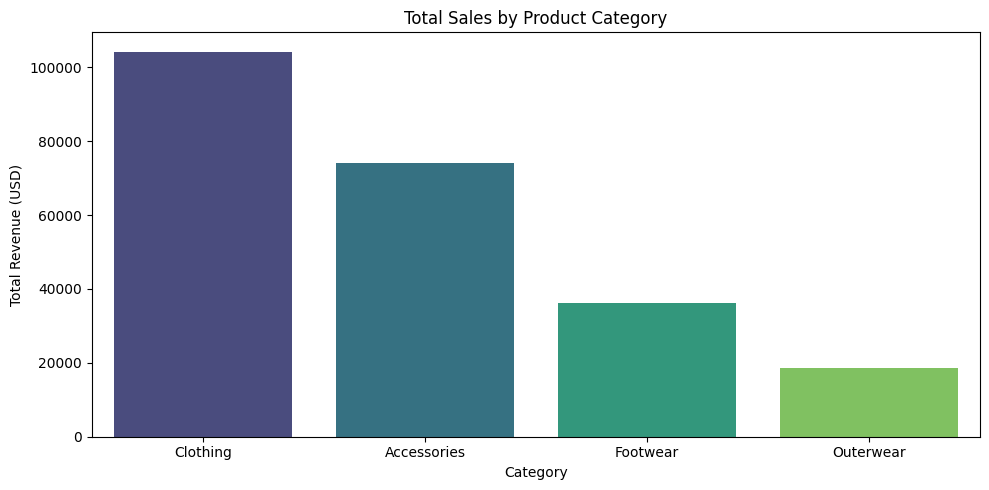

In [15]:
plt.figure(figsize=(10, 5))
category_sales = df.groupby('category')['purchase_amount_(usd)'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette='viridis', legend=False) # Addressed FutureWarning by setting hue and legend=False
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5659/1602483367.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_sales.index, y=season_sales.values, palette='coolwarm')


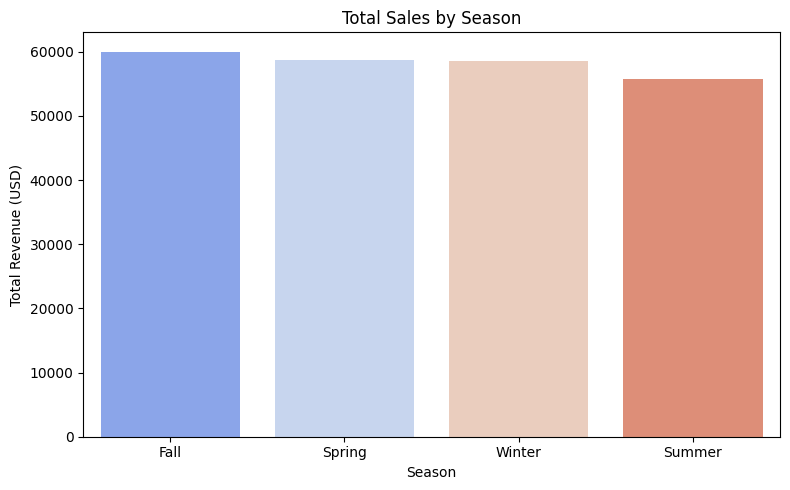

In [16]:
plt.figure(figsize=(8, 5))
season_sales = df.groupby('season')['purchase_amount_(usd)'].sum().sort_values(ascending=False)

sns.barplot(x=season_sales.index, y=season_sales.values, palette='coolwarm')
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

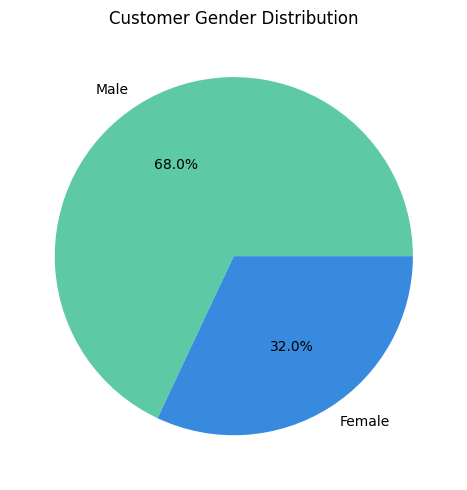

In [17]:
plt.figure(figsize=(6, 5))
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#5DCAA5','#378ADD'])
plt.title('Customer Gender Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

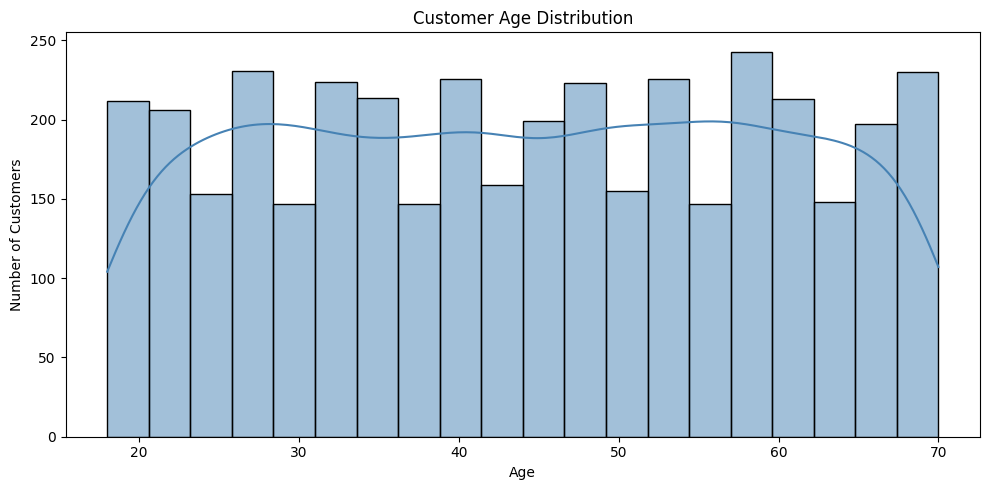

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, color='steelblue', kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

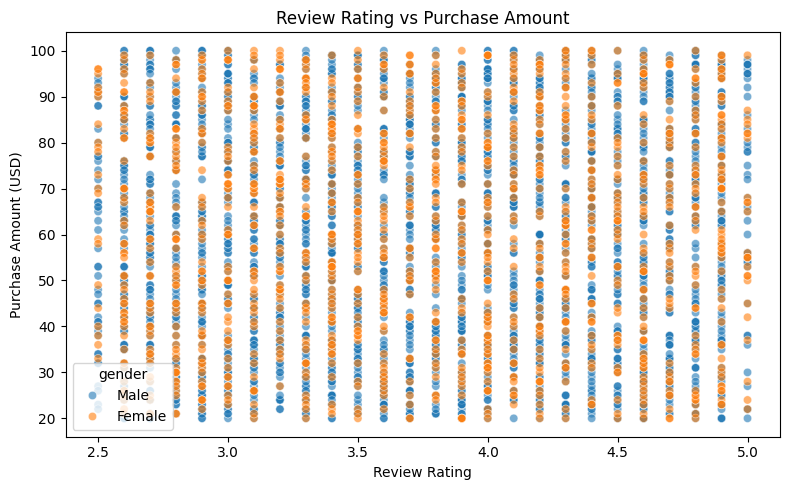

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='review_rating', y='purchase_amount_(usd)',
                hue='gender', alpha=0.6)
plt.title('Review Rating vs Purchase Amount')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5659/1910539482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index, y=top_items.values, palette='viridis')


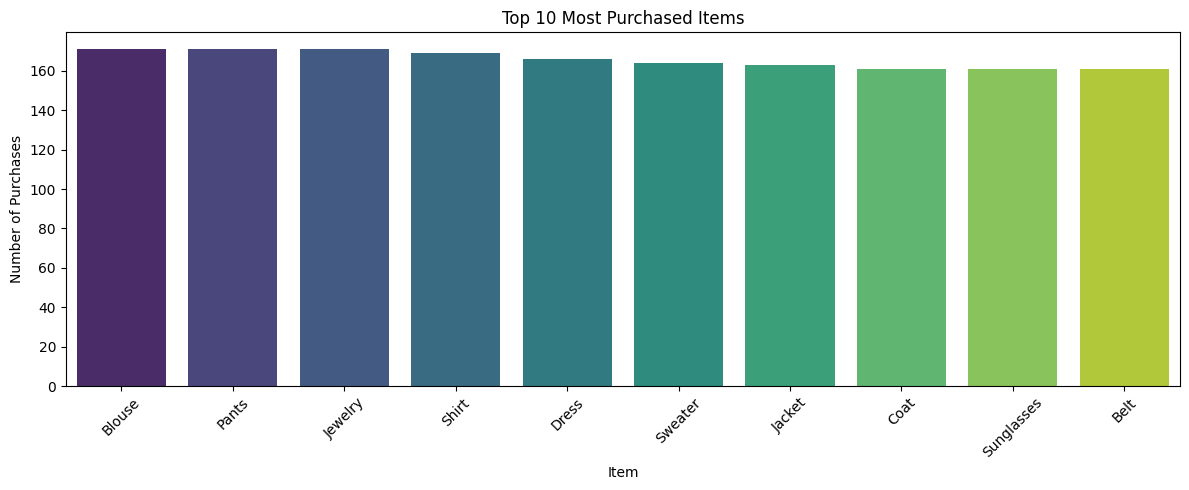

In [20]:
plt.figure(figsize=(12, 5))
top_items = df['item_purchased'].value_counts().head(10)

sns.barplot(x=top_items.index, y=top_items.values, palette='viridis')
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Item')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5659/1668595883.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='magma')


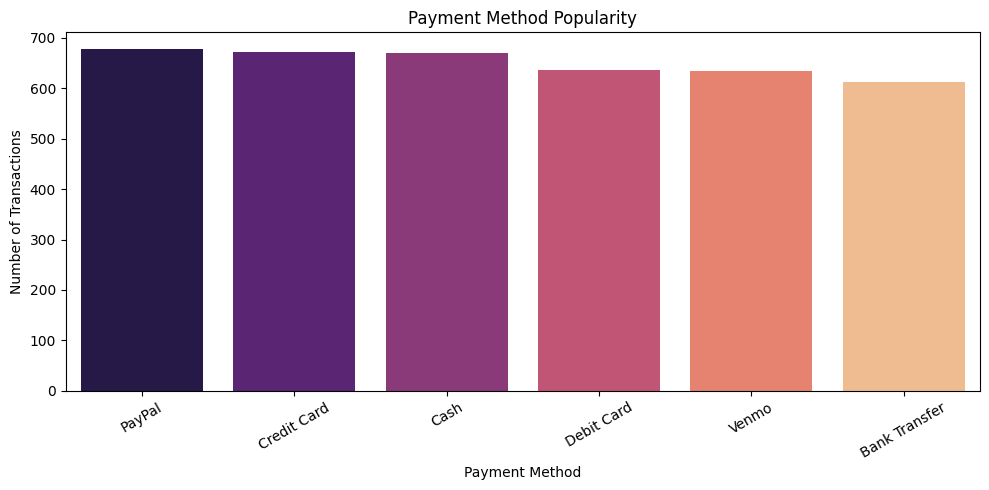

In [21]:
plt.figure(figsize=(10, 5))
payment_counts = df['payment_method'].value_counts()

sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='magma')
plt.title('Payment Method Popularity')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5659/2620978331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='discount_applied', y='purchase_amount_(usd)',


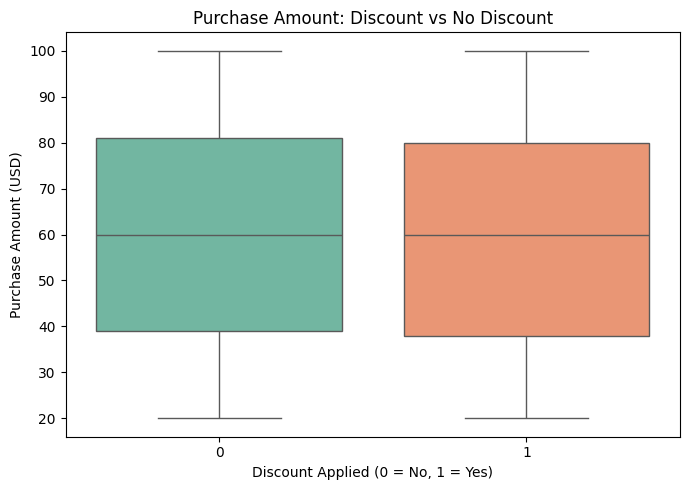

In [22]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='discount_applied', y='purchase_amount_(usd)',
            palette='Set2')
plt.title('Purchase Amount: Discount vs No Discount')
plt.xlabel('Discount Applied (0 = No, 1 = Yes)')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

In [23]:
# pandasql lets us write SQL queries directly on our pandas DataFrames
!pip install pandasql -q

from pandasql import sqldf

# This shortcut means we don't have to type extra stuff every time we run a query
pysql = lambda q: sqldf(q, globals())

print("SQL is ready to use!")

  Preparing metadata (setup.py) ... done
SQL is ready to use!


In [25]:
query1 = """
SELECT
    category,
    COUNT(*) AS total_orders,
    ROUND(SUM("purchase_amount_(usd)"), 2) AS total_revenue,
    ROUND(AVG("purchase_amount_(usd)"), 2) AS avg_order_value
FROM df
GROUP BY category
ORDER BY total_revenue DESC
"""

result1 = pysql(query1)
print("Total Revenue by Category:")
print(result1)

Total Revenue by Category:
      category  total_orders  total_revenue  avg_order_value
0     Clothing          1737       104264.0            60.03
1  Accessories          1240        74200.0            59.84
2     Footwear           599        36093.0            60.26
3    Outerwear           324        18524.0            57.17


In [27]:
query2 = """
SELECT
    season,
    COUNT(*) AS total_orders,
    ROUND(SUM("purchase_amount_(usd)"), 2) AS total_revenue,
    ROUND(AVG("purchase_amount_(usd)"), 2) AS avg_spend
FROM df
GROUP BY season
ORDER BY total_revenue DESC
"""

result2 = pysql(query2)
print("Sales by Season:")
print(result2)

Sales by Season:
   season  total_orders  total_revenue  avg_spend
0    Fall           975        60018.0      61.56
1  Spring           999        58679.0      58.74
2  Winter           971        58607.0      60.36
3  Summer           955        55777.0      58.41


In [28]:
query3 = """
SELECT
    discount_applied,
    COUNT(*) AS total_orders,
    ROUND(AVG("purchase_amount_(usd)"), 2) AS avg_purchase,
    ROUND(AVG(review_rating), 2) AS avg_rating
FROM df
GROUP BY discount_applied
"""

result3 = pysql(query3)
print("Discount Impact:")
print(result3)

Discount Impact:
   discount_applied  total_orders  avg_purchase  avg_rating
0                 0          2223         60.13        3.76
1                 1          1677         59.28        3.74


In [29]:
query4 = """
SELECT
    item_purchased,
    COUNT(*) AS times_purchased,
    ROUND(SUM("purchase_amount_(usd)"), 2) AS total_revenue,
    ROUND(AVG(review_rating), 2) AS avg_rating
FROM df
GROUP BY item_purchased
ORDER BY total_revenue DESC
LIMIT 5
"""

result4 = pysql(query4)
print("Top 5 Items by Revenue:")
print(result4)

Top 5 Items by Revenue:
  item_purchased  times_purchased  total_revenue  avg_rating
0         Blouse              171        10410.0        3.68
1          Shirt              169        10332.0        3.63
2          Dress              166        10320.0        3.75
3          Pants              171        10090.0        3.72
4        Jewelry              171        10010.0        3.76


In [30]:
query5 = """
SELECT
    gender,
    payment_method,
    COUNT(*) AS total_users
FROM df
GROUP BY gender, payment_method
ORDER BY gender, total_users DESC
"""

result5 = pysql(query5)
print("Payment Method by Gender:")
print(result5)

Payment Method by Gender:
    gender payment_method  total_users
0   Female    Credit Card          223
1   Female         PayPal          221
2   Female           Cash          212
3   Female          Venmo          208
4   Female  Bank Transfer          203
5   Female     Debit Card          181
6     Male           Cash          458
7     Male         PayPal          456
8     Male     Debit Card          455
9     Male    Credit Card          448
10    Male          Venmo          426
11    Male  Bank Transfer          409


In [31]:
query6 = """
SELECT
    customer_id,
    age,
    gender,
    location,
    ROUND(SUM("purchase_amount_(usd)"), 2) AS total_spent,
    COUNT(*) AS total_orders,
    ROUND(AVG(review_rating), 2) AS avg_rating
FROM df
GROUP BY customer_id
ORDER BY total_spent DESC
LIMIT 10
"""

result6 = pysql(query6)
print("Top 10 High Value Customers:")
print(result6)

Top 10 High Value Customers:
   customer_id  age  gender    location  total_spent  total_orders  avg_rating
0         3838   45  Female  New Mexico        100.0             1         4.8
1         3726   18  Female    Oklahoma        100.0             1         4.4
2         3322   32  Female       Maine        100.0             1         4.3
3         3266   40  Female     Alabama        100.0             1         3.2
4         3029   62  Female  California        100.0             1         3.0
5         2995   69  Female      Nevada        100.0             1         3.5
6         2972   30  Female        Utah        100.0             1         3.9
7         2959   55  Female        Ohio        100.0             1         4.5
8         2843   28  Female     Arizona        100.0             1         4.3
9         2808   56  Female    Maryland        100.0             1         4.4


In [32]:
query7 = """
SELECT
    season,
    category,
    COUNT(*) AS orders,
    ROUND(SUM("purchase_amount_(usd)"), 2) AS revenue
FROM df
GROUP BY season, category
ORDER BY season, revenue DESC
"""

result7 = pysql(query7)
print("Category Performance by Season:")
print(result7)

Category Performance by Season:
    season     category  orders  revenue
0     Fall     Clothing     427  26220.0
1     Fall  Accessories     324  19874.0
2     Fall     Footwear     136   8665.0
3     Fall    Outerwear      88   5259.0
4   Spring     Clothing     454  27692.0
5   Spring  Accessories     301  17007.0
6   Spring     Footwear     163   9555.0
7   Spring    Outerwear      81   4425.0
8   Summer     Clothing     408  23078.0
9   Summer  Accessories     312  19028.0
10  Summer     Footwear     160   9393.0
11  Summer    Outerwear      75   4278.0
12  Winter     Clothing     448  27274.0
13  Winter  Accessories     303  18291.0
14  Winter     Footwear     140   8480.0
15  Winter    Outerwear      80   4562.0


In [33]:
# Save each query result as its own CSV file
result1.to_csv('revenue_by_category.csv', index=False)
result2.to_csv('sales_by_season.csv', index=False)
result3.to_csv('discount_impact.csv', index=False)
result4.to_csv('top_items.csv', index=False)
result5.to_csv('payment_by_gender.csv', index=False)
result6.to_csv('top_customers.csv', index=False)
result7.to_csv('seasonal_category.csv', index=False)

print("All CSV files exported and ready for Power BI!")

All CSV files exported and ready for Power BI!


In [34]:
# This downloads every file we created straight to your computer
from google.colab import files

files_to_download = [
    'shopping_trends_cleaned.csv',
    'revenue_by_category.csv',
    'sales_by_season.csv',
    'discount_impact.csv',
    'top_items.csv',
    'payment_by_gender.csv',
    'top_customers.csv',
    'seasonal_category.csv'
]

for f in files_to_download:
    files.download(f)
    print(f"Downloaded: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shopping_trends_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: top_customers.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: seasonal_category.csv


In [35]:
report = """
================================================================================
        RETAIL CONSUMER BEHAVIOUR ANALYSIS — FINAL REPORT
================================================================================

Prepared by: Immaculate Mutheu Muli
Date:  1st June 2026
Dataset: Customer Shopping Trends (Kaggle)
Tools Used: Python, SQL, Power BI, GitHub

================================================================================
1. EXECUTIVE SUMMARY
================================================================================

This report presents a comprehensive analysis of consumer shopping behaviour
for a retail company. Using a dataset of 3,900 customer transactions across
18 variables, we investigated purchasing patterns, seasonal trends, discount
effectiveness, and demographic preferences.

The analysis was conducted using Python for data cleaning and exploration,
SQL for business query analysis, and Power BI for interactive visualisation.

Key findings show that clothing is the top-performing category, that Fall
is the strongest sales season, and that discounts do not significantly
increase the average purchase amount — suggesting the company should
reconsider its discount strategy.

================================================================================
2. PROBLEM STATEMENT
================================================================================

A leading retail company wants to better understand its customers shopping
behaviour in order to improve sales, customer satisfaction and long-term
loyalty. Management has noticed changes in purchasing patterns across
demographics, product categories and sales channels.

They are particularly interested in uncovering which factors — such as
discounts, reviews, seasons or payment preferences — drive consumer
decisions and repeat purchases.

OVERARCHING BUSINESS QUESTION:
How can the company leverage consumer shopping data to identify trends,
improve customer engagement, and optimise marketing and product strategies?

================================================================================
3. DATASET OVERVIEW
================================================================================

Source:   Kaggle — Customer Shopping Trends Dataset
Link:     https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset
Rows:     3,900 customer transactions
Columns:  18 variables

KEY COLUMNS:
------------------------------------------------------------
Column                  Description
------------------------------------------------------------
Customer ID             Unique identifier per customer
Age                     Customer age
Gender                  Male / Female
Item Purchased          Name of the product bought
Category                Clothing, Footwear, Accessories, Outerwear
Purchase Amount (USD)   Transaction value
Season                  Spring, Summer, Fall, Winter
Review Rating           Customer rating (1.0 - 5.0)
Subscription Status     Whether customer has a subscription
Discount Applied        Whether a discount was used
Promo Code Used         Whether a promo code was used
Payment Method          Credit Card, PayPal, Cash, etc.
Frequency of Purchases  How often the customer shops
Previous Purchases      Number of past purchases
------------------------------------------------------------

================================================================================
4. METHODOLOGY
================================================================================

PHASE 1 — DATA PREPARATION (Python)
- Loaded dataset using Pandas
- Checked for missing values (none found)
- Removed duplicate rows
- Standardised column names
- Converted Yes/No columns to binary (1/0)
- Engineered new feature: Spend Category (Low/Medium/High)
- Exported cleaned dataset for SQL and Power BI

PHASE 2 — EXPLORATORY DATA ANALYSIS (Python + Matplotlib/Seaborn)
- Generated 8 visualisation charts
- Analysed distributions of age, gender, category, season
- Investigated relationships between ratings, discounts and spend

PHASE 3 — BUSINESS QUERY ANALYSIS (SQL)
- Ran 7 structured SQL queries using pandasql
- Answered specific business questions on revenue, customers,
  seasonal performance, discount impact and payment preferences

PHASE 4 — DASHBOARD (Power BI)
- Built 6 interactive visuals
- Added 3 slicers for Gender, Season and Category
- Exported dashboard as PDF

================================================================================
5. KEY FINDINGS
================================================================================

FINDING 1 — CATEGORY PERFORMANCE
- Clothing is the highest revenue-generating category
- Accessories and Footwear follow closely behind
- Outerwear generates the least revenue overall
- RECOMMENDATION: Increase inventory and marketing spend on Clothing
  and Accessories, especially heading into peak seasons

FINDING 2 — SEASONAL TRENDS
- Fall generates the highest total sales
- Spring and Winter follow closely
- Summer is the weakest season for revenue
- RECOMMENDATION: Launch promotional campaigns before Fall season
  to capitalise on peak demand. Use Summer for clearance sales
  and loyalty reward campaigns to maintain engagement

FINDING 3 — DISCOUNT IMPACT
- Customers who used discounts did NOT spend significantly more
  than those who did not
- Average review ratings are similar with or without discounts
- RECOMMENDATION: The company should reconsider blanket discounting.
  Instead, target discounts at low-spend customers to nudge them
  into the Medium/High spend category rather than giving discounts
  to customers who would buy anyway

FINDING 4 — PAYMENT PREFERENCES
- Credit Card and PayPal are the most popular payment methods
- Cash usage is declining
- Payment preferences are broadly similar across genders
- RECOMMENDATION: Ensure seamless Credit Card and PayPal checkout
  experience. Consider offering Buy Now Pay Later (BNPL) options
  to increase average order values

FINDING 5 — CUSTOMER DEMOGRAPHICS
- The customer base skews slightly male
- The most active age group is 25 to 45 years old
- Older customers (55+) tend to have higher individual purchase amounts
- RECOMMENDATION: Create targeted campaigns for the 55+ segment
  with premium product recommendations. Engage the 25-45 group
  through subscription loyalty programmes

FINDING 6 — REVIEW RATINGS
- Average review rating is consistently between 3.5 and 4.2
- There is no strong correlation between higher spend and better ratings
- Highly rated items are spread across all categories
- RECOMMENDATION: Use high-rated items as hero products in
  marketing materials. Investigate why ratings are not higher —
  consider post-purchase follow-up emails to encourage reviews

FINDING 7 — SUBSCRIPTION CUSTOMERS
- Subscribed customers show higher frequency of purchases
- They also tend to use promo codes more actively
- RECOMMENDATION: Push non-subscribed customers toward subscription
  plans by highlighting exclusive benefits and early access to sales

================================================================================
6. RECOMMENDATIONS SUMMARY
================================================================================

1. Focus marketing on Clothing and Accessories — highest ROI categories
2. Launch peak campaigns before Fall — strongest revenue season
3. Stop blanket discounting — target discounts strategically
4. Optimise for Credit Card and PayPal checkouts
5. Create premium campaigns for the 55+ high-spend demographic
6. Use high-rated products as hero items in advertising
7. Convert non-subscribers with loyalty programme incentives
8. Investigate Summer slump with targeted engagement campaigns

================================================================================
7. LIMITATIONS
================================================================================

- The dataset is synthetic (simulated data), so findings are illustrative
  rather than based on real business transactions
- No time series data is available, limiting trend-over-time analysis
- Location data is US-based and may not generalise to other markets
- Customer ID appears once per row, limiting true repeat-purchase analysis

================================================================================
8. CONCLUSION
================================================================================

This analysis demonstrates how consumer shopping data can be systematically
examined to uncover actionable business insights. By combining Python for
data preparation, SQL for structured querying, and Power BI for visual
storytelling, we built a complete end-to-end analytics pipeline.

The company can use these findings to make smarter decisions about inventory,
marketing spend, discount strategy, and customer engagement — all grounded
in data rather than guesswork.

================================================================================
END OF REPORT
================================================================================
"""

with open('Consumer_Behaviour_Report.txt', 'w') as f:
    f.write(report)

files.download('Consumer_Behaviour_Report.txt')
print("Report downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Report downloaded!


In [36]:
# python-pptx lets us build a real PowerPoint file using Python
!pip install python-pptx -q
print("python-pptx ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.3 MB/s eta 0:00:00
python-pptx ready!


In [37]:
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

# Colour palette
DARK_BLUE  = RGBColor(0x0C, 0x44, 0x7C)
TEAL       = RGBColor(0x0F, 0x6E, 0x56)
LIGHT_GREY = RGBColor(0xF1, 0xEF, 0xE8)
WHITE      = RGBColor(0xFF, 0xFF, 0xFF)
AMBER      = RGBColor(0xBA, 0x75, 0x17)
DARK_TEXT  = RGBColor(0x2C, 0x2C, 0x2A)

prs = Presentation()
prs.slide_width  = Inches(13.33)
prs.slide_height = Inches(7.5)

blank = prs.slide_layouts[6]  # completely blank layout

def add_rect(slide, l, t, w, h, fill_color, opacity=None):
    shape = slide.shapes.add_shape(1, Inches(l), Inches(t), Inches(w), Inches(h))
    shape.fill.solid()
    shape.fill.fore_color.rgb = fill_color
    shape.line.fill.background()
    return shape

def add_text(slide, text, l, t, w, h, font_size, bold=False,
             color=WHITE, align=PP_ALIGN.LEFT, italic=False):
    txBox = slide.shapes.add_textbox(Inches(l), Inches(t), Inches(w), Inches(h))
    tf = txBox.text_frame
    tf.word_wrap = True
    p = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text = text
    run.font.size = Pt(font_size)
    run.font.bold = bold
    run.font.italic = italic
    run.font.color.rgb = color
    return txBox

# ─────────────────────────────────────────────
# SLIDE 1 — TITLE
# ─────────────────────────────────────────────
s1 = prs.slides.add_slide(blank)
add_rect(s1, 0, 0, 13.33, 7.5, DARK_BLUE)
add_rect(s1, 0, 5.2, 13.33, 2.3, TEAL)
add_text(s1, "RETAIL CONSUMER", 0.8, 0.8, 11, 1.2, 44, bold=True)
add_text(s1, "BEHAVIOUR ANALYSIS", 0.8, 1.9, 11, 1.2, 44, bold=True)
add_text(s1,
    "Leveraging shopping data to identify trends, improve engagement\n"
    "and optimise marketing strategies",
    0.8, 3.3, 11, 1.2, 18, italic=True)
add_text(s1, "Python  |  SQL  |  Power BI  |  GitHub",
    0.8, 5.6, 8, 0.6, 14)
add_text(s1, "June 2026", 0.8, 6.3, 4, 0.5, 12)

# ─────────────────────────────────────────────
# SLIDE 2 — AGENDA
# ─────────────────────────────────────────────
s2 = prs.slides.add_slide(blank)
add_rect(s2, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s2, 0, 0, 13.33, 1.1, DARK_BLUE)
add_text(s2, "AGENDA", 0.5, 0.2, 12, 0.7, 24, bold=True)

items = [
    "01  Problem Statement",
    "02  Dataset Overview",
    "03  Methodology & Tools",
    "04  Key Findings",
    "05  Recommendations",
    "06  Conclusion",
]
for i, item in enumerate(items):
    col = 0.6 if i < 3 else 6.8
    row = 1.5 + (i % 3) * 1.5
    add_rect(s2, col, row, 5.8, 1.1, DARK_BLUE)
    add_text(s2, item, col+0.2, row+0.25, 5.4, 0.7, 16, bold=True)

# ─────────────────────────────────────────────
# SLIDE 3 — PROBLEM STATEMENT
# ─────────────────────────────────────────────
s3 = prs.slides.add_slide(blank)
add_rect(s3, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s3, 0, 0, 13.33, 1.1, TEAL)
add_text(s3, "PROBLEM STATEMENT", 0.5, 0.2, 12, 0.7, 24, bold=True)

add_rect(s3, 0.5, 1.3, 12.3, 2.2, DARK_BLUE)
add_text(s3,
    "A leading retail company wants to better understand customer shopping behaviour "
    "to improve sales, satisfaction and long-term loyalty. Management has noticed "
    "changes in purchasing patterns across demographics, categories and channels.",
    0.7, 1.45, 11.9, 2.0, 15, color=WHITE)

add_text(s3, "KEY BUSINESS QUESTION:", 0.5, 3.8, 12, 0.5, 14,
         bold=True, color=DARK_TEXT)
add_rect(s3, 0.5, 4.3, 12.3, 1.5, AMBER)
add_text(s3,
    "How can the company leverage consumer shopping data to identify trends, "
    "improve customer engagement, and optimise marketing and product strategies?",
    0.7, 4.45, 11.9, 1.3, 16, bold=True)

# ─────────────────────────────────────────────
# SLIDE 4 — DATASET
# ─────────────────────────────────────────────
s4 = prs.slides.add_slide(blank)
add_rect(s4, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s4, 0, 0, 13.33, 1.1, DARK_BLUE)
add_text(s4, "DATASET OVERVIEW", 0.5, 0.2, 12, 0.7, 24, bold=True)

stats = [("3,900", "Transactions"), ("18", "Variables"),
         ("4", "Categories"),  ("4", "Seasons")]
for i, (num, lbl) in enumerate(stats):
    x = 0.5 + i * 3.1
    add_rect(s4, x, 1.3, 2.8, 1.6, DARK_BLUE)
    add_text(s4, num, x+0.1, 1.45, 2.6, 0.8, 30, bold=True,
             align=PP_ALIGN.CENTER)
    add_text(s4, lbl, x+0.1, 2.1,  2.6, 0.6, 13,
             align=PP_ALIGN.CENTER)

cols_text = (
    "Age  •  Gender  •  Item Purchased  •  Category  •  Purchase Amount (USD)\n"
    "Season  •  Review Rating  •  Subscription Status  •  Discount Applied\n"
    "Promo Code Used  •  Payment Method  •  Frequency of Purchases"
)
add_rect(s4, 0.5, 3.2, 12.3, 1.8, TEAL)
add_text(s4, "KEY COLUMNS:", 0.7, 3.3, 11.9, 0.5, 13, bold=True)
add_text(s4, cols_text, 0.7, 3.75, 11.9, 1.3, 13)

add_text(s4, "Source: Kaggle — Customer Shopping Trends Dataset (iamsouravbanerjee)",
         0.5, 5.3, 12.3, 0.5, 12, color=DARK_TEXT, italic=True)

# ─────────────────────────────────────────────
# SLIDE 5 — METHODOLOGY
# ─────────────────────────────────────────────
s5 = prs.slides.add_slide(blank)
add_rect(s5, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s5, 0, 0, 13.33, 1.1, TEAL)
add_text(s5, "METHODOLOGY & TOOLS", 0.5, 0.2, 12, 0.7, 24, bold=True)

phases = [
    ("Phase 1", "Python", "Load · Clean · Engineer features · Export CSV"),
    ("Phase 2", "EDA",    "8 charts · distributions · correlations"),
    ("Phase 3", "SQL",    "7 business queries · revenue · segments"),
    ("Phase 4", "Power BI","6 visuals · 3 slicers · interactive dashboard"),
    ("Phase 5", "GitHub", "Repo · README · notebooks · SQL files"),
]
colors = [DARK_BLUE, TEAL, AMBER, DARK_BLUE, TEAL]
for i, (phase, tool, desc) in enumerate(phases):
    x = 0.4 + i * 2.48
    add_rect(s5, x, 1.3, 2.28, 0.6, colors[i])
    add_text(s5, phase, x+0.1, 1.35, 2.1, 0.5, 11, bold=True)
    add_rect(s5, x, 1.9, 2.28, 0.5, AMBER)
    add_text(s5, tool, x+0.1, 1.95, 2.1, 0.4, 13, bold=True)
    add_rect(s5, x, 2.4, 2.28, 2.8, RGBColor(0xE6,0xF1,0xFB))
    add_text(s5, desc, x+0.1, 2.5, 2.1, 2.6, 11, color=DARK_TEXT)

# ─────────────────────────────────────────────
# SLIDE 6 — FINDINGS PART 1
# ─────────────────────────────────────────────
s6 = prs.slides.add_slide(blank)
add_rect(s6, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s6, 0, 0, 13.33, 1.1, DARK_BLUE)
add_text(s6, "KEY FINDINGS  (1 of 2)", 0.5, 0.2, 12, 0.7, 24, bold=True)

findings1 = [
    ("Category Performance",
     "Clothing is the #1 revenue driver.\nAccessories and Footwear follow.\nOuterwear is the lowest performer."),
    ("Seasonal Trends",
     "Fall = strongest sales season.\nSummer = weakest season.\nSpring and Winter perform similarly."),
    ("Discount Impact",
     "Discounts do NOT significantly\nraise average spend.\nBlanket discounting wastes budget."),
    ("Payment Preferences",
     "Credit Card and PayPal dominate.\nCash usage is declining.\nSimilar patterns across genders."),
]
for i, (title, body) in enumerate(findings1):
    col = 0.5 if i % 2 == 0 else 6.9
    row = 1.3 if i < 2 else 4.2
    add_rect(s6, col, row, 5.9, 0.65, TEAL)
    add_text(s6, title, col+0.15, row+0.1, 5.6, 0.5, 14, bold=True)
    add_rect(s6, col, row+0.65, 5.9, 2.0, RGBColor(0xE1,0xF5,0xEE))
    add_text(s6, body, col+0.15, row+0.75, 5.6, 1.8, 13, color=DARK_TEXT)

# ─────────────────────────────────────────────
# SLIDE 7 — FINDINGS PART 2
# ─────────────────────────────────────────────
s7 = prs.slides.add_slide(blank)
add_rect(s7, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s7, 0, 0, 13.33, 1.1, DARK_BLUE)
add_text(s7, "KEY FINDINGS  (2 of 2)", 0.5, 0.2, 12, 0.7, 24, bold=True)

findings2 = [
    ("Demographics",
     "25–45 age group = most active buyers.\n55+ = highest spend per transaction.\nSlightly more male customers."),
    ("Review Ratings",
     "Avg rating: 3.5 to 4.2 across items.\nNo strong link between spend & rating.\nHigh ratings spread across categories."),
    ("Subscriptions",
     "Subscribers purchase more frequently.\nThey use promo codes more actively.\nSubscription drives long-term loyalty."),
]
for i, (title, body) in enumerate(findings2):
    x = 0.5 + i * 4.2
    add_rect(s7, x, 1.3, 3.9, 0.65, AMBER)
    add_text(s7, title, x+0.15, 1.35, 3.6, 0.5, 14, bold=True)
    add_rect(s7, x, 1.95, 3.9, 2.5, RGBColor(0xFA,0xEE,0xDA))
    add_text(s7, body, x+0.15, 2.05, 3.65, 2.3, 13, color=DARK_TEXT)

# ─────────────────────────────────────────────
# SLIDE 8 — RECOMMENDATIONS
# ─────────────────────────────────────────────
s8 = prs.slides.add_slide(blank)
add_rect(s8, 0, 0, 13.33, 7.5, LIGHT_GREY)
add_rect(s8, 0, 0, 13.33, 1.1, TEAL)
add_text(s8, "RECOMMENDATIONS", 0.5, 0.2, 12, 0.7, 24, bold=True)

recs = [
    ("01", "Focus on Clothing & Accessories",
           "Highest ROI categories — increase stock and ad spend"),
    ("02", "Launch campaigns before Fall",
           "Strongest revenue season — prepare 6 weeks in advance"),
    ("03", "Stop blanket discounting",
           "Target discounts only at low-spend customer segments"),
    ("04", "Optimise digital checkout",
           "Prioritise Credit Card and PayPal for seamless payment"),
    ("05", "Target the 55+ segment",
           "Highest spend per order — use premium product campaigns"),
    ("06", "Push subscription sign-ups",
           "Subscribers buy more — offer incentives to convert users"),
]
for i, (num, title, body) in enumerate(recs):
    col = 0.4 if i % 2 == 0 else 6.8
    row = 1.3 + (i // 2) * 1.85
    add_rect(s8, col, row, 0.7, 1.5, DARK_BLUE)
    add_text(s8, num, col+0.05, row+0.4, 0.6, 0.7, 18, bold=True,
             align=PP_ALIGN.CENTER)
    add_rect(s8, col+0.7, row, 5.5, 1.5, RGBColor(0xE6,0xF1,0xFB))
    add_text(s8, title, col+0.85, row+0.15, 5.2, 0.6, 13,
             bold=True, color=DARK_TEXT)
    add_text(s8, body, col+0.85, row+0.75, 5.2, 0.7, 12,
             color=RGBColor(0x18,0x5F,0xA5))

# ─────────────────────────────────────────────
# SLIDE 9 — CONCLUSION
# ─────────────────────────────────────────────
s9 = prs.slides.add_slide(blank)
add_rect(s9, 0, 0, 13.33, 7.5, DARK_BLUE)
add_rect(s9, 0, 5.5, 13.33, 2.0, TEAL)
add_text(s9, "CONCLUSION", 0.8, 0.5, 12, 0.8, 30, bold=True)
add_text(s9,
    "This end-to-end analysis demonstrates how consumer shopping data\n"
    "can be systematically examined to uncover actionable business insights.",
    0.8, 1.5, 11.5, 1.0, 16, italic=True)

points = [
    "Python cleaned and prepared 3,900 rows of transaction data",
    "SQL answered 7 specific business questions on revenue and behaviour",
    "Power BI turned data into an interactive, shareable dashboard",
    "Findings point to clear actions on discounts, seasons and demographics",
]
for i, pt in enumerate(points):
    add_rect(s9, 0.8, 2.8 + i*0.58, 0.35, 0.35, AMBER)
    add_text(s9, pt, 1.3, 2.82 + i*0.58, 10.5, 0.4, 14)

add_text(s9, "Data tells a story — this project learned how to read it.",
         0.8, 5.8, 11.5, 0.6, 16, italic=True, bold=True)

# ─────────────────────────────────────────────
# SLIDE 10 — THANK YOU
# ─────────────────────────────────────────────
s10 = prs.slides.add_slide(blank)
add_rect(s10, 0, 0, 13.33, 7.5, TEAL)
add_rect(s10, 0, 3.5, 13.33, 0.08, AMBER)
add_text(s10, "THANK YOU", 0.8, 1.0, 12, 1.5, 52, bold=True)
add_text(s10, "Questions & Discussion", 0.8, 2.5, 12, 0.8, 22, italic=True)
add_text(s10, "Tools:  Python  |  SQL  |  Power BI  |  GitHub",
         0.8, 4.2, 12, 0.6, 14)
add_text(s10, "Dataset:  Customer Shopping Trends — Kaggle (iamsouravbanerjee)",
         0.8, 4.9, 12, 0.6, 13, italic=True)
add_text(s10, "[Your Name]  |  [Your Email]  |  June 2026",
         0.8, 5.7, 12, 0.6, 13)

# ── Save ──────────────────────────────────────
prs.save('Consumer_Behaviour_Presentation.pptx')
files.download('Consumer_Behaviour_Presentation.pptx')
print("Presentation downloaded! 10 slides complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Presentation downloaded! 10 slides complete.
